# Welcome to your new notebook
# Type here in the cell editor to add code!
Use this notebook to explore sales order data

In [8]:
df=spark.read.format("csv").option("header","true").load('Files/orders/2019.csv')
display(df.limit(100))

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 10, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 069e2c54-cd44-46c8-8ce0-9613091d6434)

In [9]:
df=spark.read.format("csv").option("header","true").load("Files/orders/2019.csv")
display(df.limit(10))

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 11, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b5a1f9b3-1b4d-434a-9fa0-02aa25797665)

In [10]:
from pyspark.sql.types import *

schema=StructType([
    StructField("SalesOrderNumber",StringType()),
    StructField("SalesOrderLineNUmber",IntegerType()),
    StructField("OrderDate",DateType()),
    StructField("CustomerName",StringType()),
    StructField("Email",StringType()),
    StructField("Item",StringType()),
    StructField("Quantity",IntegerType()),
    StructField("UnitPrice",FloatType()),
    StructField("Tax",FloatType())
])
df=spark.read.format("csv").schema(schema).load('Files/orders/*.csv')
display(df.limit(50))

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b4992449-0623-48e7-a866-b12c216ed151)

In [11]:
customer=df['CustomerName','Email']
print(customer.count())
print(customer.distinct().count())
display(customer.distinct())

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 13, Finished, Available, Finished, False)

32718
12427


SynapseWidget(Synapse.DataFrame, f6822b27-dd01-43b0-937d-b7cbfc880ff7)

In [12]:
customer=df.select('CustomerName','Email')
print(customer.count())
print(customer.distinct().count())
display(customer.distinct())

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 14, Finished, Available, Finished, False)

32718
12427


SynapseWidget(Synapse.DataFrame, 80f6a7b1-cd02-40e6-8090-86b25ca5ad39)

In [13]:
productsales=df.select("Item","Quantity").groupBy("Item").sum()
display(productsales)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 15, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d7d7dab4-8000-476e-9c44-281131810083)

In [14]:
from pyspark.sql.functions import *
yearlysales=df.select(year(col("OrderDate")).alias("Year")).groupBy("Year").count().orderBy("Year")
display(yearlysales)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 16, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a913a8c9-743b-4e5f-b69e-aa80841cfe47)

In [15]:
from pyspark.sql.functions import *

transform_df=df.withColumn("Year",year(col("OrderDate"))).withColumn("Month",month(col("OrderDate")))
display(transform_df)
transform_df=transform_df.withColumn("FirstName",split(col("CustomerName")," ").getItem(0)).withColumn("LastName",split(col("CustomerName")," ").getItem(1))
display(transform_df)
transform_df=transform_df["SalesOrderNumber", "SalesOrderLineNumber", "OrderDate", "Year", "Month", "FirstName", "LastName", "Email", "Item", "Quantity", "UnitPrice", "Tax"]
display(transform_df)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 17, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4f0b1e6d-e60c-467f-b7b6-5fb73b63a9cc)

SynapseWidget(Synapse.DataFrame, fd3d61a9-9d6d-4210-b899-987eb767faa6)

SynapseWidget(Synapse.DataFrame, 8483faa0-03f5-4a06-b079-cee1fd923699)

In [16]:
transform_df.write.mode("overwrite").parquet('Files/tranformed_data/orders')
print("Transformed data saved !!!")

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 18, Finished, Available, Finished, False)

Transformed data saved !!!


In [17]:
orders_df=spark.read.format("parquet").load("Files/tranformed_data/orders")
display(orders_df)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 8a31bc67-463a-4746-9268-692cb3aaa702)

In [18]:
orders_df.write.partitionBy("Year","Month").mode("overwrite").parquet("Files/Partitioned_data")
print("Transformed data saved")

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 20, Finished, Available, Finished, False)

Transformed data saved


In [19]:
orders_2021_df=spark.read.format("parquet").load("Files/Partitioned_data/Year=2021/Month=*")
display(orders_2021_df)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 1b21d752-9c01-4f09-b99a-f7662554c114)

In [25]:
# df.write.format("delta").saveAsTable("SalesOrders")
spark.sql("DESCRIBE EXTENDED salesorders").show(truncate=False)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 27, Finished, Available, Finished, False)

+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|col_name                    |data_type                                                                                                                                |comment|
+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|SalesOrderNumber            |string                                                                                                                                   |NULL   |
|SalesOrderLineNUmber        |int                                                                                                                                      |NULL   |
|OrderDate                   |date                                                                                 

In [28]:
df=spark.sql("SELECT * FROM dbo.salesorders  limit 1000")
display(df)

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 30, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d5ad44e4-50fa-4fcf-979c-e6a50d6d22a9)

In [30]:
%%sql
select year(OrderDate) as OrderYear,
round(sum((UnitPrice*Quantity)+Tax),2) as GrossRevenue
from salesorders
group by year(OrderDate)
order by OrderYear;

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 32, Finished, Available, Finished, False)

<Spark SQL result set with 3 rows and 2 fields>

In [31]:
%%sql
select * from salesorders;

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 33, Finished, Available, Finished, False)

<Spark SQL result set with 1000 rows and 9 fields>

In [34]:
sqlQuery="SELECT CAST (YEAR(OrderDate) as char(4)) as OrderYear,sum((UnitPrice*Quantity)+Tax) as GrossRevenue,COUNT(DISTINCT SalesOrderNumber) as YearlyCounts from salesorders group by cast(year(OrderDate) as CHAR(4)) order by OrderYear"
df_spark=spark.sql(sqlQuery)
df_spark.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 36, Finished, Available, Finished, False)

+---------+--------------------+------------+
|OrderYear|        GrossRevenue|YearlyCounts|
+---------+--------------------+------------+
|     2019|   4172169.969970703|        1201|
|     2020|   6882259.268127441|        2733|
|     2021|1.1547835291696548E7|       12525|
+---------+--------------------+------------+



StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 37, Finished, Available, Finished, False)

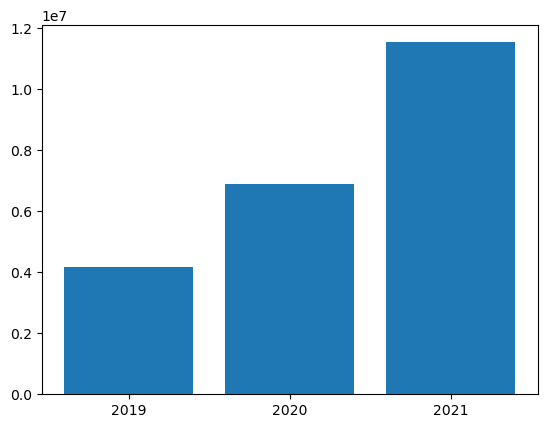

In [35]:
from matplotlib import pyplot as plt

# matplotlib requires a Pandas dataframe, not a Spark one
df_sales = df_spark.toPandas()

# Create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'])

# Display the plot
plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 38, Finished, Available, Finished, False)

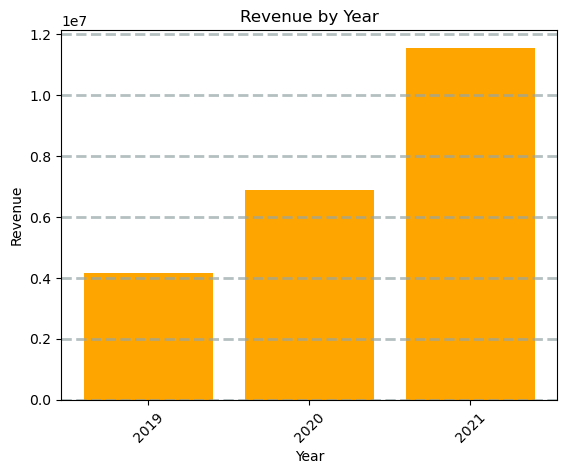

In [36]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')

# Customize the chart
plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

# Show the figure
plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 39, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

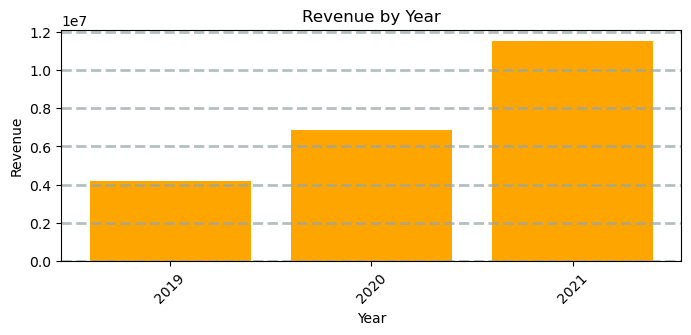

In [37]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a Figure
fig = plt.figure(figsize=(8,3))

# Create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')

# Customize the chart
plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

# Show the figure
plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 40, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

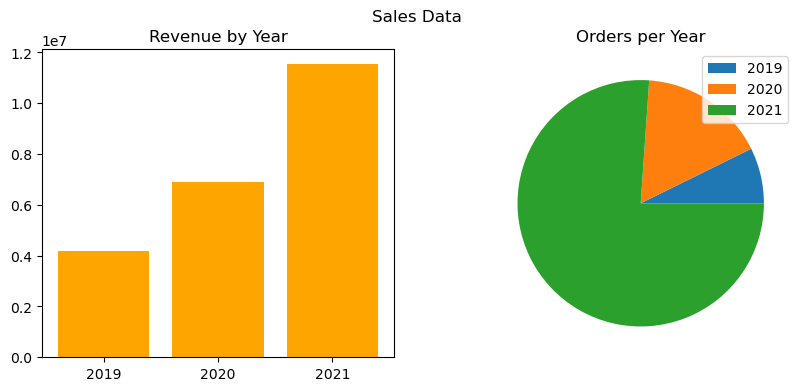

In [38]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a figure for 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# Create a bar plot of revenue by year on the first axis
ax[0].bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')
ax[0].set_title('Revenue by Year')

# Create a pie chart of yearly order counts on the second axis
ax[1].pie(df_sales['YearlyCounts'])
ax[1].set_title('Orders per Year')
ax[1].legend(df_sales['OrderYear'])

# Add a title to the Figure
fig.suptitle('Sales Data')

# Show the figure
plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 41, Finished, Available, Finished, False)

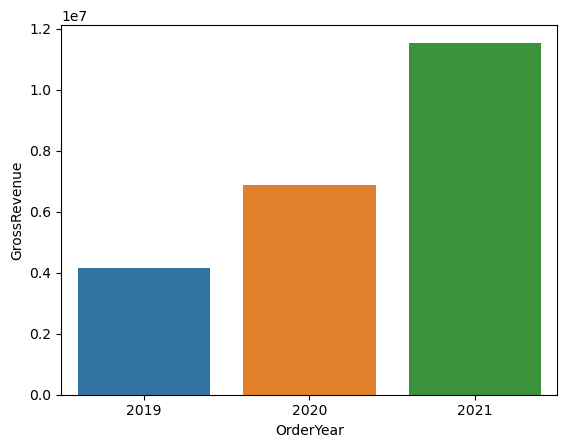

In [39]:
import seaborn as sns

# Clear the plot area
plt.clf()

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 42, Finished, Available, Finished, False)

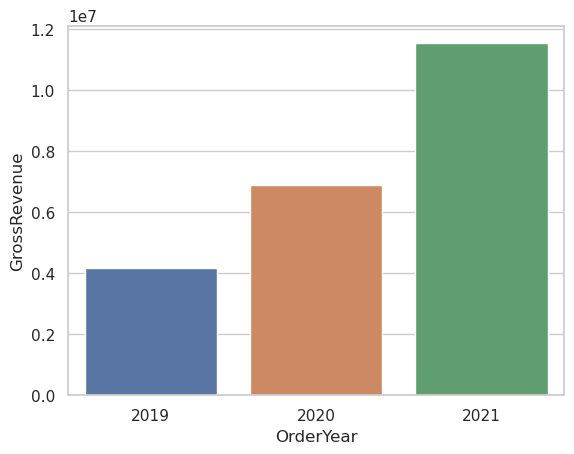

In [40]:
import seaborn as sns

# Clear the plot area
plt.clf()

# Set the visual theme for seaborn
sns.set_theme(style="whitegrid")

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, 5d9e1742-5e9e-40a0-9486-af7bfeecda4a, 43, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


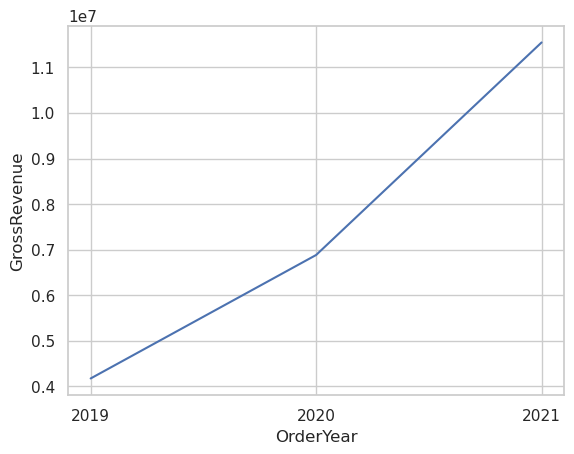

In [41]:
import seaborn as sns

# Clear the plot area
plt.clf()

# Create a line chart
ax = sns.lineplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()